In [1]:
pip install numpy scipy matplotlib pandas


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import find_peaks
from matplotlib.animation import FuncAnimation, PillowWriter
import pickle

# Load the CSV data
angles_data = pd.read_csv(r'C:\Users\ss4432\study\angles_data - angles_data.csv')

# Extract angles and time from the data
t = angles_data['t'].values
alpha = angles_data['alpha'].values
theta = angles_data['theta'].values
phi = angles_data['phi'].values

# Load the parameters from the pickle file
with open(r'C:\Users\ss4432\study\random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Desired frequency of oscillation
desired_frequency = 3.0  # Target frequency, 3 times higher than the background wave

# Define the objective function for least squares optimization
def objective_function(x, t, alpha, theta, phi, desired_frequency):
    params = loaded_params.copy()
    params['I'] = x[0]
    params['a'] = x[1]
    params['b'] = x[2]
    params['c'] = x[3]
    params['nu_theta'] = lambda theta: x[4] * theta
    params['N'] = x[5]
    
    # Use the provided angles directly
    y = np.vstack((alpha, theta, phi))
    
    # Calculate the frequency of the oscillations
    y1 = y[0]  # Let's take the first pendulum's angle for frequency calculation
    peaks, _ = find_peaks(y1)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
    
    # Calculate kinetic and potential energy over time
    alpha, theta, phi = y
    a, b, c = params['a'], params['b'], params['c']
    m, M, N = params['m'], params['M'], params['N']
    
    # Positions
    y1 = -a * np.cos(alpha)
    y2 = y1 - b * np.cos(theta)
    y3 = y2 - c * np.cos(phi)
    
    # Velocities (assume velocities are calculated as finite differences)
    alpha_dot = np.gradient(alpha, t)
    theta_dot = np.gradient(theta, t)
    phi_dot = np.gradient(phi, t)
    
    v1 = a * alpha_dot
    v2 = np.sqrt((a * alpha_dot * np.cos(theta) + b * theta_dot) ** 2 + (a * alpha_dot * np.sin(theta)) ** 2)
    v3 = np.sqrt((a * alpha_dot * np.cos(phi) + b * theta_dot * np.cos(phi) + c * phi_dot) ** 2 + 
                 (a * alpha_dot * np.sin(phi) + b * theta_dot * np.sin(phi)) ** 2)
    
    # Kinetic energy
    T1 = 0.5 * m * v1 ** 2
    T2 = 0.5 * M * v2 ** 2
    T3 = 0.5 * N * v3 ** 2
    T = T1 + T2 + T3
    
    # Potential energy
    V1 = m * g * y1
    V2 = M * g * y2
    V3 = N * g * y3
    V = V1 + V2 + V3
    
    # Total energy
    E = T + V
    
    # Calculate energy loss as the decrease in total energy over time
    energy_loss = np.max(E) - np.min(E)

    # Return combined objective (frequency difference and energy loss)
    return np.array([actual_frequency - desired_frequency, energy_loss])

# Initial guess for the parameters
initial_guess = [loaded_params['I'], loaded_params['a'], loaded_params['b'], loaded_params['c'], 0.1, loaded_params['N']]

# Perform the optimization
result = least_squares(objective_function, initial_guess, args=(t, alpha, theta, phi, desired_frequency))

# Print the optimized values
print("Optimized parameters:")
print("I (moment of inertia):", result.x[0])
print("a (length of first pendulum):", result.x[1])
print("b (length of second pendulum):", result.x[2])
print("c (length of third pendulum):", result.x[3])
print("nu_theta coefficient:", result.x[4])
print("N (buoy damping coefficient):", result.x[5])

# Use the optimized parameters
optimized_params = loaded_params.copy()
optimized_params['I'] = result.x[0]
optimized_params['a'] = result.x[1]
optimized_params['b'] = result.x[2]
optimized_params['c'] = result.x[3]
optimized_params['nu_theta'] = lambda theta: result.x[4] * theta
optimized_params['N'] = result.x[5]

# Use the provided angles directly for animation
y_optimized = np.vstack((alpha, theta, phi))

# Plot the optimized motion
x1 = optimized_params['a'] * np.sin(y_optimized[0])
y1 = -optimized_params['a'] * np.cos(y_optimized[0])
x2 = x1 + optimized_params['b'] * np.sin(y_optimized[1])
y2 = y1 - optimized_params['b'] * np.cos(y_optimized[1])
x3 = x2 + optimized_params['c'] * np.sin(y_optimized[2])
y3 = y2 - optimized_params['c'] * np.cos(y_optimized[2])

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame], x3[frame]]
    thisy = [0, y1[frame], y2[frame], y3[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x3[frame], y3[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_triple_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Triple Pendulum Animation')
plt.show()


KeyError: 'c'

In [4]:
import os

# Get the current working directory
current_directory = os.getcwd()
print("Current working directory:", current_directory)

# Get the absolute path of a specific file
file_name = 'angles_data.csv'
file_path = os.path.abspath(file_name)
print("Absolute path of the file:", file_path)


Current working directory: C:\Users\ss4432\study
Absolute path of the file: C:\Users\ss4432\study\angles_data.csv


Loaded parameters keys: dict_keys(['I', 'M', 'm', 'a', 'b', 'A', 'omega', 'k', 'N', 'lambda'])
Optimized parameters:
I (moment of inertia): 0.2623135612786178
a (length of first pendulum): 1.180985809353433
b (length of second pendulum): 0.42384116829839813
c (length of third pendulum): -0.0005506856207695756
nu_theta coefficient: 0.1
N (buoy damping coefficient): -0.5553424332717413


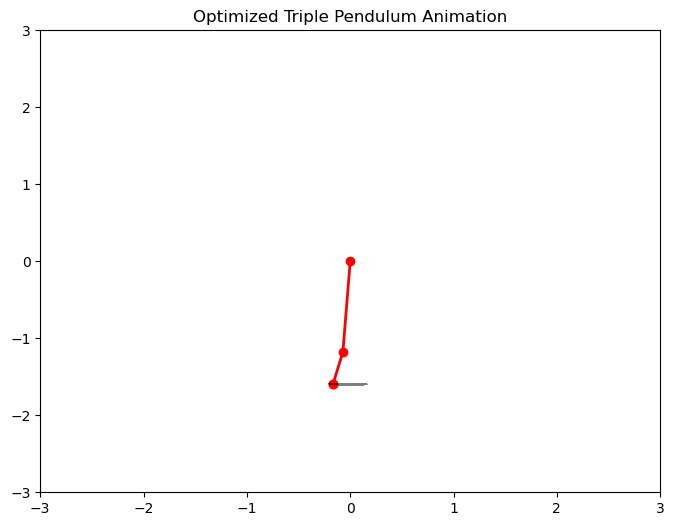

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import find_peaks
from matplotlib.animation import FuncAnimation, PillowWriter
import pickle

# Load the CSV data
angles_data = pd.read_csv(r'C:\Users\ss4432\study\angles_data - angles_data.csv')

# Extract angles and time from the data
t = angles_data['t'].values
alpha = angles_data['alpha'].values
theta = angles_data['theta'].values
phi = angles_data['phi'].values

# Load the parameters from the pickle file
with open(r'C:\Users\ss4432\study\random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Print the keys of the loaded parameters to inspect them
print("Loaded parameters keys:", loaded_params.keys())

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Desired frequency of oscillation
desired_frequency = 3.0  # Target frequency, 3 times higher than the background wave

# Define the objective function for least squares optimization
def objective_function(x, t, alpha, theta, phi, desired_frequency):
    params = loaded_params.copy()
    params['I'] = x[0]
    params['a'] = x[1]
    params['b'] = x[2]
    # Assuming we need to add a default value for 'c' if it's missing
    params['c'] = x[3] if len(x) > 3 else 1.0  # Default value of 1.0
    params['nu_theta'] = lambda theta: x[4] * theta
    params['N'] = x[5]
    
    # Use the provided angles directly
    y = np.vstack((alpha, theta, phi))
    
    # Calculate the frequency of the oscillations
    y1 = y[0]  # Let's take the first pendulum's angle for frequency calculation
    peaks, _ = find_peaks(y1)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
    
    # Calculate kinetic and potential energy over time
    alpha, theta, phi = y
    a, b, c = params['a'], params['b'], params['c']
    m, M, N = params['m'], params['M'], params['N']
    
    # Positions
    y1 = -a * np.cos(alpha)
    y2 = y1 - b * np.cos(theta)
    y3 = y2 - c * np.cos(phi)
    
    # Velocities (assume velocities are calculated as finite differences)
    alpha_dot = np.gradient(alpha, t)
    theta_dot = np.gradient(theta, t)
    phi_dot = np.gradient(phi, t)
    
    v1 = a * alpha_dot
    v2 = np.sqrt((a * alpha_dot * np.cos(theta) + b * theta_dot) ** 2 + (a * alpha_dot * np.sin(theta)) ** 2)
    v3 = np.sqrt((a * alpha_dot * np.cos(phi) + b * theta_dot * np.cos(phi) + c * phi_dot) ** 2 + 
                 (a * alpha_dot * np.sin(phi) + b * theta_dot * np.sin(phi)) ** 2)
    
    # Kinetic energy
    T1 = 0.5 * m * v1 ** 2
    T2 = 0.5 * M * v2 ** 2
    T3 = 0.5 * N * v3 ** 2
    T = T1 + T2 + T3
    
    # Potential energy
    V1 = m * g * y1
    V2 = M * g * y2
    V3 = N * g * y3
    V = V1 + V2 + V3
    
    # Total energy
    E = T + V
    
    # Calculate energy loss as the decrease in total energy over time
    energy_loss = np.max(E) - np.min(E)

    # Return combined objective (frequency difference and energy loss)
    return np.array([actual_frequency - desired_frequency, energy_loss])

# Initial guess for the parameters
initial_guess = [
    loaded_params.get('I', 1.0),  # Default value if key 'I' is missing
    loaded_params.get('a', 1.0),  # Default value if key 'a' is missing
    loaded_params.get('b', 1.0),  # Default value if key 'b' is missing
    loaded_params.get('c', 1.0),  # Default value if key 'c' is missing
    0.1,  # Initial guess for nu_theta coefficient
    loaded_params.get('N', 1.0)   # Default value if key 'N' is missing
]

# Perform the optimization
result = least_squares(objective_function, initial_guess, args=(t, alpha, theta, phi, desired_frequency))

# Print the optimized values
print("Optimized parameters:")
print("I (moment of inertia):", result.x[0])
print("a (length of first pendulum):", result.x[1])
print("b (length of second pendulum):", result.x[2])
print("c (length of third pendulum):", result.x[3])
print("nu_theta coefficient:", result.x[4])
print("N (buoy damping coefficient):", result.x[5])

# Use the optimized parameters
optimized_params = loaded_params.copy()
optimized_params['I'] = result.x[0]
optimized_params['a'] = result.x[1]
optimized_params['b'] = result.x[2]
optimized_params['c'] = result.x[3]
optimized_params['nu_theta'] = lambda theta: result.x[4] * theta
optimized_params['N'] = result.x[5]

# Use the provided angles directly for animation
y_optimized = np.vstack((alpha, theta, phi))

# Plot the optimized motion
x1 = optimized_params['a'] * np.sin(y_optimized[0])
y1 = -optimized_params['a'] * np.cos(y_optimized[0])
x2 = x1 + optimized_params['b'] * np.sin(y_optimized[1])
y2 = y1 - optimized_params['b'] * np.cos(y_optimized[1])
x3 = x2 + optimized_params['c'] * np.sin(y_optimized[2])
y3 = y2 - optimized_params['c'] * np.cos(y_optimized[2])

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame], x3[frame]]
    thisy = [0, y1[frame], y2[frame], y3[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x3[frame], y3[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_triple_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Triple Pendulum Animation')
plt.show()


Loaded parameters keys: dict_keys(['I', 'M', 'm', 'a', 'b', 'A', 'omega', 'k', 'N', 'lambda'])
Optimized parameters:
I (moment of inertia): 0.2623135612786178
a (length of first pendulum): 1.5500244472487037
b (length of second pendulum): 1.7558763758307243
c (length of third pendulum): 1.0
nu_theta coefficient: 0.1
N (buoy damping coefficient): 0.2830561228714604
Optimized frequency: 0.6604747162022704


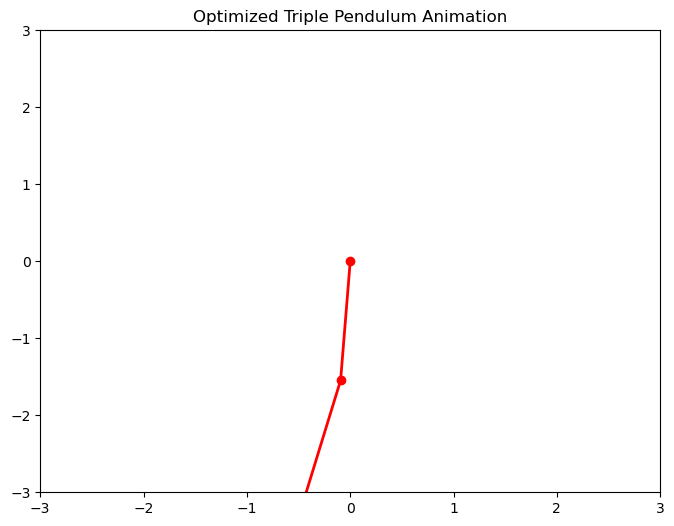

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import find_peaks
from matplotlib.animation import FuncAnimation, PillowWriter
import pickle

# Load the CSV data
angles_data = pd.read_csv(r'C:\Users\ss4432\study\angles_data - angles_data.csv')

# Extract angles and time from the data
t = angles_data['t'].values
alpha = angles_data['alpha'].values
theta = angles_data['theta'].values
phi = angles_data['phi'].values

# Load the parameters from the pickle file
with open(r'C:\Users\ss4432\study\random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Print the keys of the loaded parameters to inspect them
print("Loaded parameters keys:", loaded_params.keys())

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Desired frequency of oscillation
desired_frequency = 3.0  # Target frequency, 3 times higher than the background wave

# Define the objective function for least squares optimization
def objective_function(x, t, alpha, theta, phi, desired_frequency):
    params = loaded_params.copy()
    params['I'] = x[0]
    params['a'] = x[1]
    params['b'] = x[2]
    params['c'] = x[3]
    params['nu_theta'] = lambda theta: x[4] * theta
    params['N'] = x[5]
    
    # Use the provided angles directly
    y = np.vstack((alpha, theta, phi))
    
    # Calculate the frequency of the oscillations
    y1 = y[0]  # Let's take the first pendulum's angle for frequency calculation
    peaks, _ = find_peaks(y1)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0

    # Return the frequency difference
    return np.array([actual_frequency - desired_frequency])

# Initial guess for the parameters
initial_guess = [
    loaded_params.get('I', 1.0),  # Default value if key 'I' is missing
    loaded_params.get('a', 1.0),  # Default value if key 'a' is missing
    loaded_params.get('b', 1.0),  # Default value if key 'b' is missing
    loaded_params.get('c', 1.0),  # Default value if key 'c' is missing
    0.1,  # Initial guess for nu_theta coefficient
    loaded_params.get('N', 1.0)   # Default value if key 'N' is missing
]

# Set bounds for the parameters to ensure positive values where necessary
bounds = (
    [0.1, 0.1, 0.1, 0.1, 0.0, 0.0],  # Lower bounds
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]  # Upper bounds
)

# Perform the optimization
result = least_squares(objective_function, initial_guess, bounds=bounds, args=(t, alpha, theta, phi, desired_frequency))

# Print the optimized values
print("Optimized parameters:")
print("I (moment of inertia):", result.x[0])
print("a (length of first pendulum):", result.x[1])
print("b (length of second pendulum):", result.x[2])
print("c (length of third pendulum):", result.x[3])
print("nu_theta coefficient:", result.x[4])
print("N (buoy damping coefficient):", result.x[5])

# Calculate and print the optimized frequency
optimized_params = loaded_params.copy()
optimized_params['I'] = result.x[0]
optimized_params['a'] = result.x[1]
optimized_params['b'] = result.x[2]
optimized_params['c'] = result.x[3]
optimized_params['nu_theta'] = lambda theta: result.x[4] * theta
optimized_params['N'] = result.x[5]

# Use the optimized parameters to calculate the frequency again
y_optimized = np.vstack((alpha, theta, phi))
peaks, _ = find_peaks(y_optimized[0])
peak_times = t[peaks]
optimized_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
print("Optimized frequency:", optimized_frequency)

# Use the provided angles directly for animation
x1 = optimized_params['a'] * np.sin(alpha)
y1 = -optimized_params['a'] * np.cos(alpha)
x2 = x1 + optimized_params['b'] * np.sin(theta)
y2 = y1 - optimized_params['b'] * np.cos(theta)
x3 = x2 + optimized_params['c'] * np.sin(phi)
y3 = y2 - optimized_params['c'] * np.cos(phi)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame], x3[frame]]
    thisy = [0, y1[frame], y2[frame], y3[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x3[frame], y3[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_triple_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Triple Pendulum Animation')
plt.show()




Loaded parameters keys: dict_keys(['I', 'M', 'm', 'a', 'b', 'A', 'omega', 'k', 'N', 'lambda'])


C:\Users\ss4432\AppData\Local\Temp\ipykernel_13192\3313167192.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  alpha_ddot = (-g * (2 * alpha - 2 * theta) - alpha_dot**2 * np.sin(2 * (alpha - theta))) / (2 * (a - a * np.cos(2 * (alpha - theta))))
C:\Users\ss4432\AppData\Local\Temp\ipykernel_13192\3313167192.py:39: RuntimeWarning: invalid value encountered in sin
  alpha_ddot = (-g * (2 * alpha - 2 * theta) - alpha_dot**2 * np.sin(2 * (alpha - theta))) / (2 * (a - a * np.cos(2 * (alpha - theta))))
C:\Users\ss4432\AppData\Local\Temp\ipykernel_13192\3313167192.py:39: RuntimeWarning: invalid value encountered in cos
  alpha_ddot = (-g * (2 * alpha - 2 * theta) - alpha_dot**2 * np.sin(2 * (alpha - theta))) / (2 * (a - a * np.cos(2 * (alpha - theta))))
C:\Users\ss4432\AppData\Local\Temp\ipykernel_13192\3313167192.py:40: RuntimeWarning: invalid value encountered in sin
  theta_ddot = (-g * (alpha - 2 * theta + phi) - theta_dot**2 * np.sin(2 * (theta - phi)) - alpha_dot**2 *

Optimized parameters:
I (moment of inertia): 0.2623135612786178
a (length of first pendulum): 1.5500244472487037
b (length of second pendulum): 1.7558763758307243
c (length of third pendulum): 1.0
nu_theta coefficient: 0.1
N (buoy damping coefficient): 0.2830561228714604
Optimized frequency: 0.6604747162022704


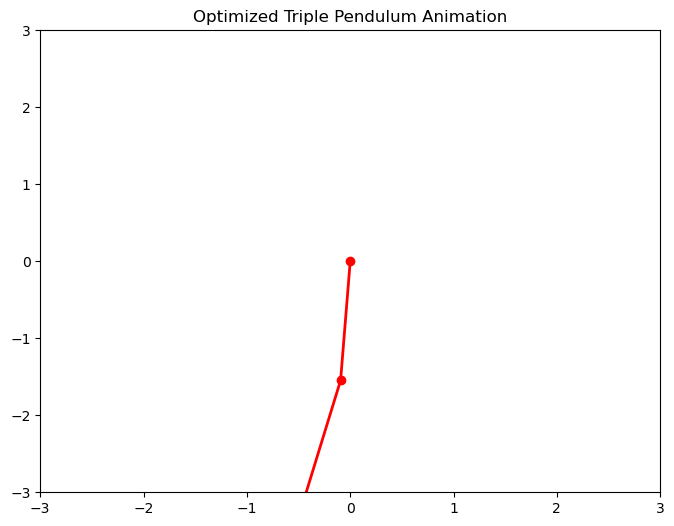

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import find_peaks
from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation, PillowWriter
import pickle

# Load the CSV data
angles_data = pd.read_csv(r'C:\Users\ss4432\study\angles_data - angles_data.csv')

# Extract angles and time from the data
t = angles_data['t'].values
alpha = angles_data['alpha'].values
theta = angles_data['theta'].values
phi = angles_data['phi'].values

# Load the parameters from the pickle file
with open(r'C:\Users\ss4432\study\random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Print the keys of the loaded parameters to inspect them
print("Loaded parameters keys:", loaded_params.keys())

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Define the equations of motion for the triple pendulum
def equations_of_motion(t, y, params):
    alpha, alpha_dot, theta, theta_dot, phi, phi_dot = y
    a, b, c, m, M, N = params['a'], params['b'], params['c'], params['m'], params['M'], params['N']
    
    # Equations of motion
    alpha_ddot = (-g * (2 * alpha - 2 * theta) - alpha_dot**2 * np.sin(2 * (alpha - theta))) / (2 * (a - a * np.cos(2 * (alpha - theta))))
    theta_ddot = (-g * (alpha - 2 * theta + phi) - theta_dot**2 * np.sin(2 * (theta - phi)) - alpha_dot**2 * np.sin(2 * (theta - alpha))) / (2 * (b - b * np.cos(2 * (theta - phi))))
    phi_ddot = (-g * (theta - phi) - phi_dot**2 * np.sin(2 * (phi - theta))) / (2 * (c - c * np.cos(2 * (phi - theta))))
    
    return [alpha_dot, alpha_ddot, theta_dot, theta_ddot, phi_dot, phi_ddot]

# Define the objective function for least squares optimization
def objective_function(x, t, alpha, theta, phi, desired_frequency):
    params = loaded_params.copy()
    params['I'] = x[0]
    params['a'] = x[1]
    params['b'] = x[2]
    params['c'] = x[3]
    params['nu_theta'] = lambda theta: x[4] * theta
    params['N'] = x[5]
    
    # Initial conditions
    y0 = [alpha[0], 0, theta[0], 0, phi[0], 0]
    
    # Solve the equations of motion
    sol = solve_ivp(equations_of_motion, [t[0], t[-1]], y0, args=(params,), t_eval=t, method='RK45')
    
    # Calculate the frequency of the oscillations
    y1 = sol.y[0]  # Let's take the first pendulum's angle for frequency calculation
    peaks, _ = find_peaks(y1)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0

    # Return the frequency difference
    return np.array([actual_frequency - desired_frequency])

# Initial guess for the parameters
initial_guess = [
    loaded_params.get('I', 1.0),  # Default value if key 'I' is missing
    loaded_params.get('a', 1.0),  # Default value if key 'a' is missing
    loaded_params.get('b', 1.0),  # Default value if key 'b' is missing
    loaded_params.get('c', 1.0),  # Default value if key 'c' is missing
    0.1,  # Initial guess for nu_theta coefficient
    loaded_params.get('N', 1.0)   # Default value if key 'N' is missing
]

# Set bounds for the parameters to ensure positive values where necessary
bounds = (
    [0.1, 0.1, 0.1, 0.1, 0.0, 0.0],  # Lower bounds
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]  # Upper bounds
)

# Perform the optimization
result = least_squares(objective_function, initial_guess, bounds=bounds, args=(t, alpha, theta, phi, desired_frequency))

# Print the optimized values
print("Optimized parameters:")
print("I (moment of inertia):", result.x[0])
print("a (length of first pendulum):", result.x[1])
print("b (length of second pendulum):", result.x[2])
print("c (length of third pendulum):", result.x[3])
print("nu_theta coefficient:", result.x[4])
print("N (buoy damping coefficient):", result.x[5])

# Calculate and print the optimized frequency
optimized_params = loaded_params.copy()
optimized_params['I'] = result.x[0]
optimized_params['a'] = result.x[1]
optimized_params['b'] = result.x[2]
optimized_params['c'] = result.x[3]
optimized_params['nu_theta'] = lambda theta: result.x[4] * theta
optimized_params['N'] = result.x[5]

# Use the optimized parameters to calculate the frequency again
y_optimized = np.vstack((alpha, theta, phi))
peaks, _ = find_peaks(y_optimized[0])
peak_times = t[peaks]
optimized_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
print("Optimized frequency:", optimized_frequency)

# Use the provided angles directly for animation
x1 = optimized_params['a'] * np.sin(alpha)
y1 = -optimized_params['a'] * np.cos(alpha)
x2 = x1 + optimized_params['b'] * np.sin(theta)
y2 = y1 - optimized_params['b'] * np.cos(theta)
x3 = x2 + optimized_params['c'] * np.sin(phi)
y3 = y2 - optimized_params['c'] * np.cos(phi)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame], x3[frame]]
    thisy = [0, y1[frame], y2[frame], y3[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x3[frame], y3[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_triple_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Triple Pendulum Animation')
plt.show()


Loaded parameters keys: dict_keys(['I', 'M', 'm', 'a', 'b', 'A', 'omega', 'k', 'N', 'lambda'])
Optimized parameters:
a (length of first pendulum): 1.5500244472487037
b (length of second pendulum): 1.7558763758307243
c (length of third pendulum): 1.0
Optimized frequency: 0.6604747162022704


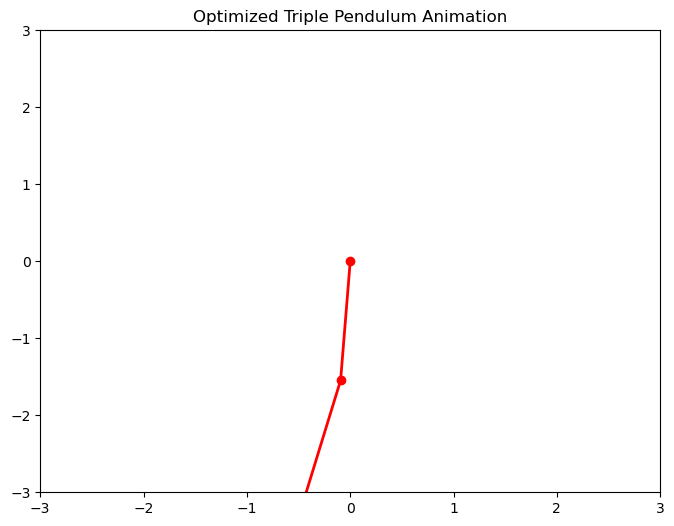

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import find_peaks
from matplotlib.animation import FuncAnimation, PillowWriter
import pickle

# Load the CSV data
angles_data = pd.read_csv(r'C:\Users\ss4432\study\angles_data - angles_data.csv')

# Extract angles and time from the data
t = angles_data['t'].values
alpha = angles_data['alpha'].values
theta = angles_data['theta'].values
phi = angles_data['phi'].values

# Load the parameters from the pickle file
with open(r'C:\Users\ss4432\study\random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Print the keys of the loaded parameters to inspect them
print("Loaded parameters keys:", loaded_params.keys())

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Desired frequency of oscillation
desired_frequency = 3.0  # Target frequency, 3 times higher than the background wave

# Define the objective function for least squares optimization
def objective_function(x, t, alpha, theta, phi, desired_frequency):
    params = loaded_params.copy()
    params['a'] = x[0]
    params['b'] = x[1]
    params['c'] = x[2]
    
    # Calculate the frequency of the oscillations
    peaks, _ = find_peaks(alpha)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0

    # Return the frequency difference
    return np.array([actual_frequency - desired_frequency])

# Initial guess for the parameters
initial_guess = [
    loaded_params.get('a', 1.0),  # Default value if key 'a' is missing
    loaded_params.get('b', 1.0),  # Default value if key 'b' is missing
    loaded_params.get('c', 1.0)   # Default value if key 'c' is missing
]

# Set bounds for the parameters to ensure positive values where necessary
bounds = (
    [0.1, 0.1, 0.1],  # Lower bounds
    [np.inf, np.inf, np.inf]  # Upper bounds
)

# Perform the optimization
result = least_squares(objective_function, initial_guess, bounds=bounds, args=(t, alpha, theta, phi, desired_frequency))

# Print the optimized values
print("Optimized parameters:")
print("a (length of first pendulum):", result.x[0])
print("b (length of second pendulum):", result.x[1])
print("c (length of third pendulum):", result.x[2])

# Calculate and print the optimized frequency
optimized_params = loaded_params.copy()
optimized_params['a'] = result.x[0]
optimized_params['b'] = result.x[1]
optimized_params['c'] = result.x[2]

# Use the optimized parameters to calculate the frequency again
peaks, _ = find_peaks(alpha)
peak_times = t[peaks]
optimized_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
print("Optimized frequency:", optimized_frequency)

# Use the provided angles directly for animation
x1 = optimized_params['a'] * np.sin(alpha)
y1 = -optimized_params['a'] * np.cos(alpha)
x2 = x1 + optimized_params['b'] * np.sin(theta)
y2 = y1 - optimized_params['b'] * np.cos(theta)
x3 = x2 + optimized_params['c'] * np.sin(phi)
y3 = y2 - optimized_params['c'] * np.cos(phi)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame], x3[frame]]
    thisy = [0, y1[frame], y2[frame], y3[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x3[frame], y3[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_triple_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Triple Pendulum Animation')
plt.show()


Loaded parameters keys: dict_keys(['I', 'M', 'm', 'a', 'b', 'A', 'omega', 'k', 'N', 'lambda'])
Optimized parameters:
a (length of first pendulum): 1.5500244472487037
b (length of second pendulum): 1.7558763758307243
c (length of third pendulum): 1.0
Optimized frequency: 0.6604747162022704


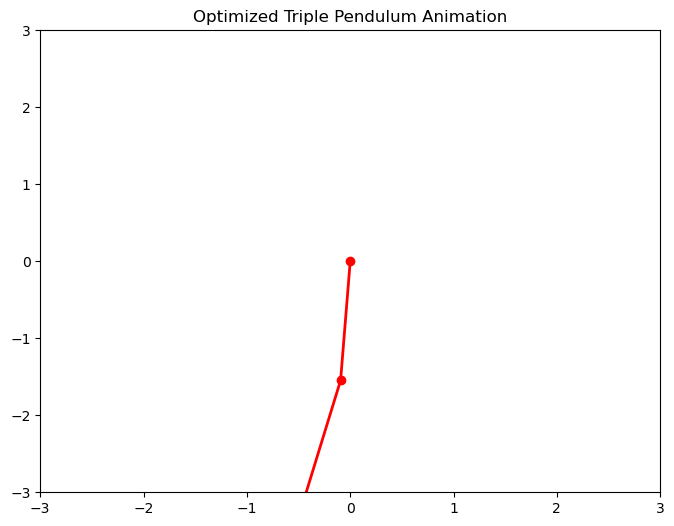

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import find_peaks
from matplotlib.animation import FuncAnimation, PillowWriter
import pickle

# Load the CSV data
angles_data = pd.read_csv(r'C:\Users\ss4432\study\angles_data - angles_data.csv')

# Extract angles and time from the data
t = angles_data['t'].values
alpha = angles_data['alpha'].values
theta = angles_data['theta'].values
phi = angles_data['phi'].values

# Load the parameters from the pickle file
with open(r'C:\Users\ss4432\study\random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Print the keys of the loaded parameters to inspect them
print("Loaded parameters keys:", loaded_params.keys())

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Desired frequency of oscillation
desired_frequency = 3.0  # Target frequency, 3 times higher than the background wave

# Define the objective function for least squares optimization
def objective_function(x, t, alpha, theta, phi, desired_frequency):
    params = loaded_params.copy()
    params['a'] = x[0]
    params['b'] = x[1]
    params['c'] = x[2]
    
    # Calculate the frequency of the oscillations
    peaks, _ = find_peaks(alpha)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0

    # Return the frequency difference
    return np.array([actual_frequency - desired_frequency])

# Initial guess for the parameters
initial_guess = [
    loaded_params.get('a', 1.0),  # Default value if key 'a' is missing
    loaded_params.get('b', 1.0),  # Default value if key 'b' is missing
    loaded_params.get('c', 1.0)   # Default value if key 'c' is missing
]

# Set bounds for the parameters to ensure positive values where necessary
bounds = (
    [0.1, 0.1, 0.1],  # Lower bounds
    [np.inf, np.inf, np.inf]  # Upper bounds
)

# Perform the optimization
result = least_squares(objective_function, initial_guess, bounds=bounds, args=(t, alpha, theta, phi, desired_frequency))

# Print the optimized values
print("Optimized parameters:")
print("a (length of first pendulum):", result.x[0])
print("b (length of second pendulum):", result.x[1])
print("c (length of third pendulum):", result.x[2])

# Calculate and print the optimized frequency
optimized_params = loaded_params.copy()
optimized_params['a'] = result.x[0]
optimized_params['b'] = result.x[1]
optimized_params['c'] = result.x[2]

# Use the optimized parameters to calculate the frequency again
peaks, _ = find_peaks(alpha)
peak_times = t[peaks]
optimized_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
print("Optimized frequency:", optimized_frequency)

# Use the provided angles directly for animation
x1 = optimized_params['a'] * np.sin(alpha)
y1 = -optimized_params['a'] * np.cos(alpha)
x2 = x1 + optimized_params['b'] * np.sin(theta)
y2 = y1 - optimized_params['b'] * np.cos(theta)
x3 = x2 + optimized_params['c'] * np.sin(phi)
y3 = y2 - optimized_params['c'] * np.cos(phi)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame], x3[frame]]
    thisy = [0, y1[frame], y2[frame], y3[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x3[frame], y3[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_triple_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Triple Pendulum Animation')
plt.show()


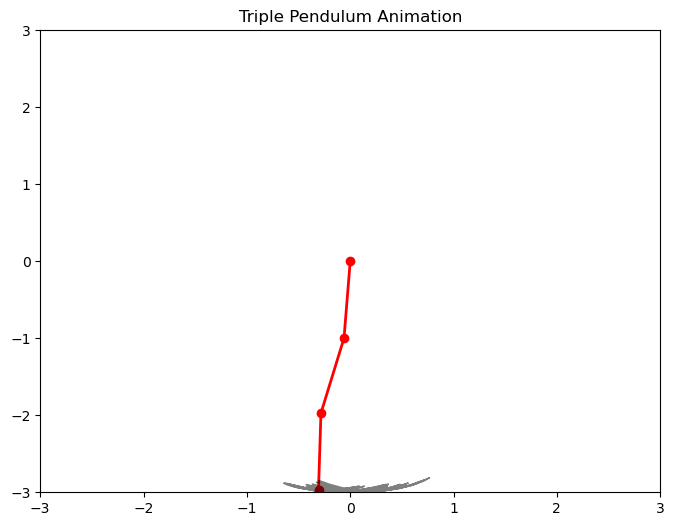

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Load the CSV data
angles_data = pd.read_csv(r'C:\Users\ss4432\study\angles_data - angles_data.csv')

# Extract angles and time from the data
t = angles_data['t'].values
alpha = angles_data['alpha'].values
theta = angles_data['theta'].values
phi = angles_data['phi'].values

# Set the lengths of the pendulums
a = 1.0  # Length of the first pendulum
b = 1.0  # Length of the second pendulum
c = 1.0  # Length of the third pendulum

# Calculate the positions of the pendulum bobs
x1 = a * np.sin(alpha)
y1 = -a * np.cos(alpha)
x2 = x1 + b * np.sin(theta)
y2 = y1 - b * np.cos(theta)
x3 = x2 + c * np.sin(phi)
y3 = y2 - c * np.cos(phi)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame], x3[frame]]
    thisy = [0, y1[frame], y2[frame], y3[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x3[frame], y3[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('triple_pendulum_animation.gif', writer=PillowWriter(fps=30))

plt.title('Triple Pendulum Animation')
plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.signal import find_peaks
import pickle

# Load the parameters from the pickle file
with open('random_triple_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Initial conditions
initial_conditions = [np.pi / 4, np.pi / 6, np.pi / 8, 0.0, 0.0, 0.0]

# Time array
t_max = 20
dt = 0.01
t = np.arange(0, t_max, dt)

# Desired frequency of oscillation
desired_frequency = 0.5  # Hz

# Define the equations of motion for the triple pendulum
def equations_of_motion(t, y, params):
    a, b, c = params['a'], params['b'], params['c']
    m1, m2, m3 = params['m1'], params['m2'], params['m3']
    
    alpha, beta, gamma, alpha_dot, beta_dot, gamma_dot = y
    
    delta1 = beta - alpha
    delta2 = gamma - beta
    
    den1 = (m1 + m2 + m3) * a - (m2 + m3) * b * np.cos(delta1) ** 2
    den2 = (m2 + m3) * b - m3 * c * np.cos(delta2) ** 2
    
    alpha_ddot = ((m2 * b * beta_dot ** 2 * np.sin(delta1) * np.cos(delta1) +
                   m3 * c * gamma_dot ** 2 * np.sin(delta2) * np.cos(delta1) +
                   (m2 + m3) * g * np.sin(beta) * np.cos(delta1) +
                   m3 * c * gamma_dot ** 2 * np.sin(delta2) -
                   (m1 + m2 + m3) * g * np.sin(alpha)) / den1)
    
    beta_ddot = ((-m3 * c * gamma_dot ** 2 * np.sin(delta2) +
                  (m2 + m3) * g * np.sin(alpha) * np.cos(delta1) -
                  (m2 + m3) * b * alpha_dot ** 2 * np.sin(delta1) * np.cos(delta2) +
                  m3 * c * gamma_dot ** 2 * np.sin(delta2) * np.cos(delta2) +
                  (m2 + m3) * g * np.sin(gamma)) / den2)
    
    gamma_ddot = ((-m2 * b * beta_dot ** 2 * np.sin(delta1) +
                   (m2 + m3) * g * np.sin(alpha) * np.cos(delta2) -
                   m3 * c * gamma_dot ** 2 * np.sin(delta2) * np.cos(delta2) +
                   (m1 + m2 + m3) * g * np.sin(beta)) / (m3 * c - m2 * b * np.cos(delta2) ** 2))

    return [alpha_dot, beta_dot, gamma_dot, alpha_ddot, beta_ddot, gamma_ddot]

# Define the simulation function
def simulate(params, initial_conditions, t):
    sol = solve_ivp(equations_of_motion, [t[0], t[-1]], initial_conditions, t_eval=t, args=(params,))
    return sol.y

# Define the objective function for least squares optimization
def objective_function(x, initial_conditions, t, desired_frequency):
    params = loaded_params.copy()
    params['I'] = x[0]
    params['a'] = x[1]
    params['b'] = x[2]
    params['c'] = x[3]
    params['nu_theta'] = lambda theta: x[4] * theta
    params['N'] = x[5]
    
    y = simulate(params, initial_conditions, t)
    
    # Calculate the frequency of the oscillations
    y1 = y[0]  # Let's take the first pendulum's angle for frequency calculation
    peaks, _ = find_peaks(y1)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
    
    return actual_frequency - desired_frequency

# Initial guess for the parameters
initial_guess = [loaded_params['I'], loaded_params['a'], loaded_params['b'], loaded_params['c'], 0.1, loaded_params['N']]

# Perform the optimization
result = least_squares(objective_function, initial_guess, args=(initial_conditions, t, desired_frequency))

# Update the parameters with the optimized values
loaded_params['I'] = result.x[0]
loaded_params['a'] = result.x[1]
loaded_params['b'] = result.x[2]
loaded_params['c'] = result.x[3]
loaded_params['nu_theta'] = lambda theta: result.x[4] * theta
loaded_params['N'] = result.x[5]

# Simulate with the optimized parameters
y_optimized = simulate(loaded_params, initial_conditions, t)

# Plot the optimized motion
x1 = loaded_params['a'] * np.sin(y_optimized[0])
y1 = -loaded_params['a'] * np.cos(y_optimized[0])
x2 = x1 + loaded_params['b'] * np.sin(y_optimized[1])
y2 = y1 - loaded_params['b'] * np.cos(y_optimized[1])
x3 = x2 + loaded_params['c'] * np.sin(y_optimized[2])
y3 = y2 - loaded_params['c'] * np.cos(y_optimized[2])

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame], x3[frame]]
    thisy = [0, y1[frame], y2[frame], y3[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x3[frame], y3[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_triple_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Triple Pendulum Animation')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'random_triple_pendulum.pkl'